In [1]:
# Plot data Rijkswaterstaat stations
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

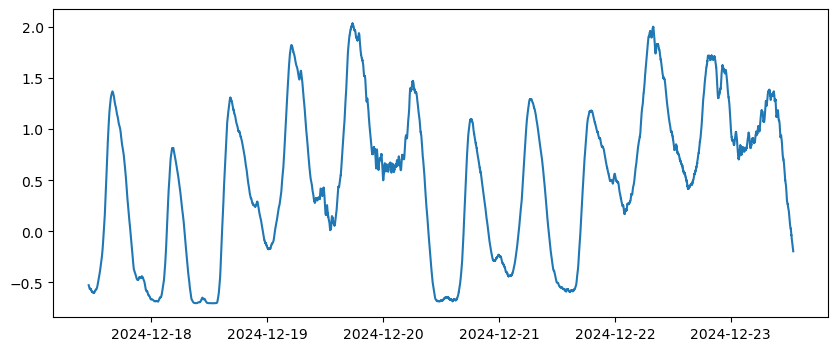

In [16]:
# PRESSURE SENSOR: S3.BS3 ----------------------------------------------------------------------
nc_path = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'
with xr.open_dataset(nc_path) as ds:
    t_full = ds.t_full.values
    zs_rolling = ds.zs.rolling(t_full=16*60*10, center=True).mean()  # 10 min moving avg
    
    ds['zs_rolling'] = zs_rolling
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_full_cut = t_full[::16*60] # every 60 seconds
    #zs_rolling = zs_rolling.values[::16*60]

    ds_P3 = ds.sel(t_full=t_full_cut)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(ds_P3.t_full, ds_P3.zs_rolling, label='Pressure sensor S3.BS3')

np.datetime64('2024-12-17T11:00:00.000000000')

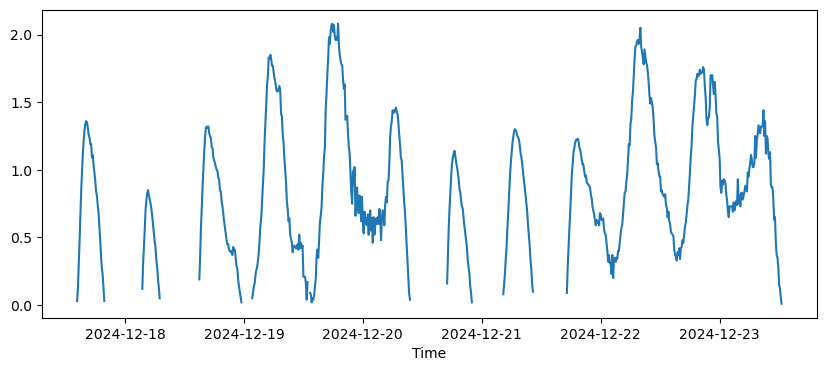

In [17]:
nc_waterlevel = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waterlevel_SCHEVNGN.nc'

with xr.open_dataset(nc_waterlevel) as ds_waterlevel:
    ds_waterlevel = ds_waterlevel.sel(t=slice(ds_P3.t_full.values[0], ds_P3.t_full.values[-1]))
    t_Scheveningen = ds_waterlevel.t
    zs_Scheveningen = ds_waterlevel.waterlevel / 100
    # make zs_Schevenigen nan where below-0.6m
    zs_Scheveningen = zs_Scheveningen.where(zs_Scheveningen > 0)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(t_Scheveningen, zs_Scheveningen, label='RWS Scheveningen')
ax.set_xlabel('Time')

t_Scheveningen[0].values

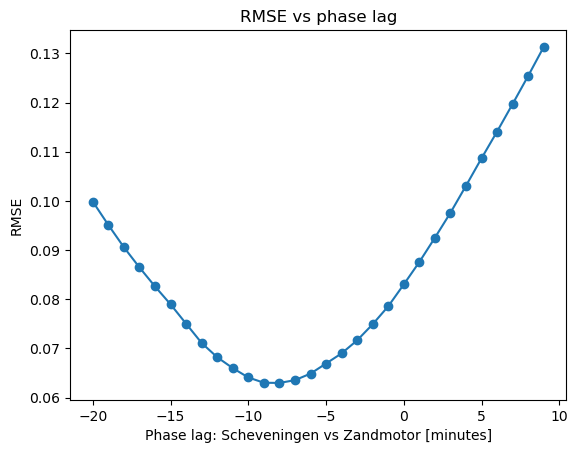

np.float64(0.08302604309808054)

In [19]:
# zs_Scheveningen
zs_P3 = ds_P3.zs_rolling[::10].values  # every 10th minute to match RWS data frequency
zs_P3
# Calculate R2
rmse = np.sqrt(np.mean((zs_Scheveningen - zs_P3) ** 2))
rmse

#loop
rmse = np.zeros(30)
for i in range(30):
    zs_P3 = ds_P3.zs_rolling[i::10].values
    zs_P3 = zs_P3[:874] # use 874 for deploymnent 1, 2578 for deployment 2
    # Ensure both arrays are the same length
    rmse[i] = np.sqrt(np.mean((zs_Scheveningen[2:] - zs_P3) ** 2)) #scheveningen: skip first two values, for 20min shift

plt.figure()
plt.plot(range(-20,10), rmse, marker='o')
plt.xlabel('Phase lag: Scheveningen vs Zandmotor [minutes]')
plt.ylabel('RMSE')
plt.title('RMSE vs phase lag')
plt.show()
rmse[20]


In [69]:
# Function to get NetCDF file path for Pressure Sensors (P_BS)
def get_nc_P_BS(section, bs, period, processing_step='raw'):
    """
    Returns the full path to the NetCDF file for a given section, sensor type+number (BS#), period, and processing step.
    processing_step: 'raw', 'QC', or 'processed'
    """
    # Select folder and filename pattern based on processing_step
    period_num = period.split()[-1]  # e.g., 'period 2' -> '2'
    if processing_step == 'raw':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\raw NetCDF"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) raw data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) raw data - {period}.nc"
    elif processing_step == 'QC':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\QC"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) QC P_rel - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) QC P_air - {period}.nc"
    elif processing_step == 'processed':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\processed"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) processed data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) processed data - {period}.nc"
    else:
        raise ValueError("processing_step must be 'raw', 'QC', or 'processed'")

    # Try RBR first, then Ossi
    if section.lower().startswith('ref'):
        for brand in ['RBR', 'Ossi']:
            fname = ref_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath
    else:
        for brand in ['RBR', 'Ossi']:
            fname = fname_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath

    raise FileNotFoundError(f"File not found for section={section}, bs={bs}, period={period}, processing_step={processing_step}")

# Example usage:
# path = get_nc_P_BS('S1', 'BS2', 'period 2', processing_step='QC')
# print(path)


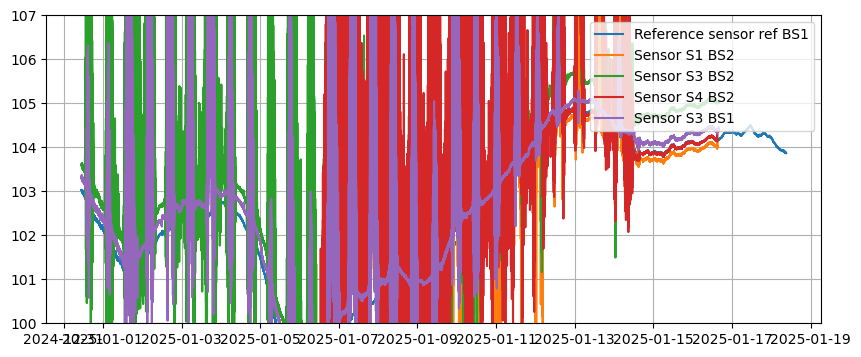

In [88]:
fig = plt.figure(figsize=(10, 6))

# plot reference sensor
path = get_nc_P_BS('ref', 'BS1', 'period 2', processing_step='QC')

with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_air/1000 # convert Pa to cm
    plt.plot(t, p, label='Reference sensor ref BS1')


path = get_nc_P_BS('S1', 'BS2', 'period 2', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_abs/1000 # convert Pa to cm
    plt.plot(t, p, label='Sensor S1 BS2')

path = get_nc_P_BS('S3', 'BS2', 'period 2', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_abs/1000 # convert Pa to cm
    plt.plot(t, p, label='Sensor S3 BS2')

path = get_nc_P_BS('S4', 'BS2', 'period 2', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_abs/1000 # convert Pa to cm
    plt.plot(t, p, label='Sensor S4 BS2')

path = get_nc_P_BS('S3', 'BS1', 'period 2', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_abs/1000 # convert Pa to cm
    plt.plot(t, p, label='Sensor S3 BS1')

#set ylim
plt.ylim(100, 107)
# plot legend at upper right
plt.grid(True)
plt.legend(loc='upper right')

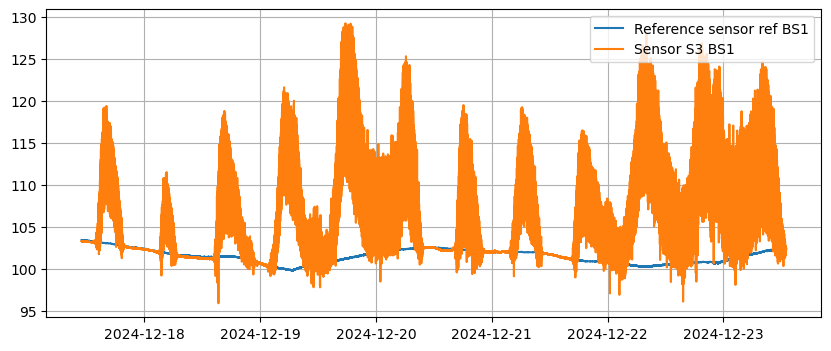

In [87]:
fig = plt.figure(figsize=(10, 4))

# plot reference sensor
path = get_nc_P_BS('ref', 'BS1', 'period 1', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_air/1000 # convert Pa to cm
    plt.plot(t, p, label='Reference sensor ref BS1')


path = get_nc_P_BS('S1', 'BS2', 'period 1', processing_step='QC')
with xr.open_dataset(path) as ds:
    t = ds.t
    p = ds.p_abs/1000 # convert Pa to cm
    plt.plot(t, p, label='Sensor S3 BS1')

#set ylim
#plt.ylim(100, 110)
# plot legend at upper right
plt.grid(True)
plt.legend(loc='upper right')

In [86]:
path = get_nc_P_BS('S1', 'BS2', 'period 1', processing_step='QC')
nc_path

'O:\\HybridDune experiment\\data RBR, OSSI\\netcdf\\processed\\Deployment period 2\\Pressure sensor S3 P_BS3 (RBR) processed data - period 2.nc'